# Preparing phenotype data from Lamin

In [ ]:
# GDSC = ln.Artifact.get("DHxqYydkn9ioXZIB0000") 
# GDSC2 = ln.Artifact.get("dfhJLapzyySHcm2n0000") 
# PRISM = ln.Artifact.get("TQXr4EjQ63GILFiX0002") 
# CTRP = ln.Artifact.get("7M6IIRQCd5IN6tqK0000") 


# SCORE = ln.Artifact.get("nVgxTPYjZ88nLQBd0000") 
# LINCS - > ?

In [1]:
import os
import sys
import zarr
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd

/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [2]:
import lamindb as ln
import scanpy as sc
import wetlab as wl
import bionty as bt
import numpy as np
import os
import sys
sys.path.append('/lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/CellFlow2/scripts')


→ defaulting to local storage: /ictstr01/groups/ml01/projects/big_perturbation/datasets
→ connected lamindb: theislab/pertmodeling


In [4]:
ln.connect('https://lamin.ai/theislab/pertmodeling')


→ doing nothing, already connected lamindb: theislab/pertmodeling
→ connected lamindb: theislab/pertmodeling


In [ ]:
# GDSC = ln.Artifact.get("DHxqYydkn9ioXZIB0000").load()
# GDSC.write_h5ad("/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet/GDSC.h5ad")
# GDSC2 = ln.Artifact.get("dfhJLapzyySHcm2n0000").load()
# GDSC2.write_h5ad("/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet/GDSC2.h5ad")
# PRISM = ln.Artifact.get("TQXr4EjQ63GILFiX0002").load()
# PRISM.write_h5ad("/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet/PRISM.h5ad")
# CTRP = ln.Artifact.get("7M6IIRQCd5IN6tqK0000").load()
# CTRP.write_h5ad("/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet/CTRP.h5ad")

# SCORE = ln.Artifact.get("nVgxTPYjZ88nLQBd0000").load()
# SCORE.write_h5ad("/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet/SCORE.h5ad")

! run input wasn't tracked, call `ln.track()` and re-run
! run input wasn't tracked, call `ln.track()` and re-run
! run input wasn't tracked, call `ln.track()` and re-run
! run input wasn't tracked, call `ln.track()` and re-run
! run input wasn't tracked, call `ln.track()` and re-run


## 1. Load all Prophet datasets

In [4]:
DATA_DIR = "/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet"

datasets = {}
for name in ["GDSC", "GDSC2", "PRISM", "CTRP", "SCORE"]:
    path = f"{DATA_DIR}/{name}.h5ad"
    datasets[name] = ad.read_h5ad(path)
    print(f"{name}: {datasets[name].shape[0]:>10,} obs | "
          f"{datasets[name].obs['cell_line'].nunique():>5} cell lines | "
          f"{datasets[name].obs['pert_name'].nunique():>6} perturbations | "
          f"assay: {datasets[name].obs['assay'].iloc[0]}")

GDSC:    242,036 obs |   967 cell lines |    286 perturbations | assay: Flourescence-based cell viability
GDSC2:    109,712 obs |   122 cell lines |   2025 perturbations | assay: Flourescence-based cell viability
PRISM:  2,240,925 obs |   567 cell lines |   4046 perturbations | assay: Median flourescence intensity (MFI)
CTRP:    387,258 obs |   887 cell lines |    698 perturbations | assay: CellTiter-Glo
SCORE:  5,660,082 obs |   318 cell lines |  17799 perturbations | assay: fitness assays


## 2. Dataset overview table

In [5]:
import matplotlib.pyplot as plt

summary_rows = []
for name, adata in datasets.items():
    x = adata.X.flatten()
    pert_type = adata.obs["pert_type"].iloc[0]
    # Check if combinatorial
    is_combo = ";" in str(adata.obs["pert_name"].iloc[0]) if name == "GDSC2" else False
    
    summary_rows.append({
        "Dataset": name,
        "Pert Type": pert_type,
        "Combinatorial": is_combo,
        "Assay": adata.obs["assay"].iloc[0],
        "N Observations": adata.shape[0],
        "N Cell Lines": adata.obs["cell_line"].nunique(),
        "N Perturbations": adata.obs["pert_name"].nunique(),
        "Value Mean": f"{x.mean():.3f}",
        "Value Std": f"{x.std():.3f}",
        "Value Min": f"{x.min():.3f}",
        "Value Max": f"{x.max():.3f}",
        "Sparsity (% filled)": f"{adata.shape[0] / (adata.obs['cell_line'].nunique() * adata.obs['pert_name'].nunique()) * 100:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Dataset,Pert Type,Combinatorial,Assay,N Observations,N Cell Lines,N Perturbations,Value Mean,Value Std,Value Min,Value Max,Sparsity (% filled)
0,GDSC,compound,False,Flourescence-based cell viability,242036,967,286,0.513,0.122,0.000,1.000,87.5%
1,GDSC2,compound,True,Flourescence-based cell viability,109712,122,2025,0.542,0.128,0.000,1.000,44.4%
2,PRISM,compound,False,Median flourescence intensity (MFI),2240925,567,4046,0.638,0.075,0.000,1.000,97.7%
3,CTRP,compound,False,CellTiter-Glo,387258,887,698,0.925,0.038,0.000,1.000,62.5%
4,SCORE,genetic,False,fitness assays,5660082,318,17799,0.701,0.058,0.000,1.000,100.0%


## 3. Phenotype (outcome value) distributions per dataset

Each dataset stores a single scalar value in `X` (already normalized to [0,1] by Prophet).
- **GDSC / GDSC2**: ln(IC50) of drug viability
- **PRISM**: Log2FC viability (MFI-based)
- **CTRP**: IC50 viability (CellTiter-Glo)
- **SCORE**: Gene essentiality (CERES score)

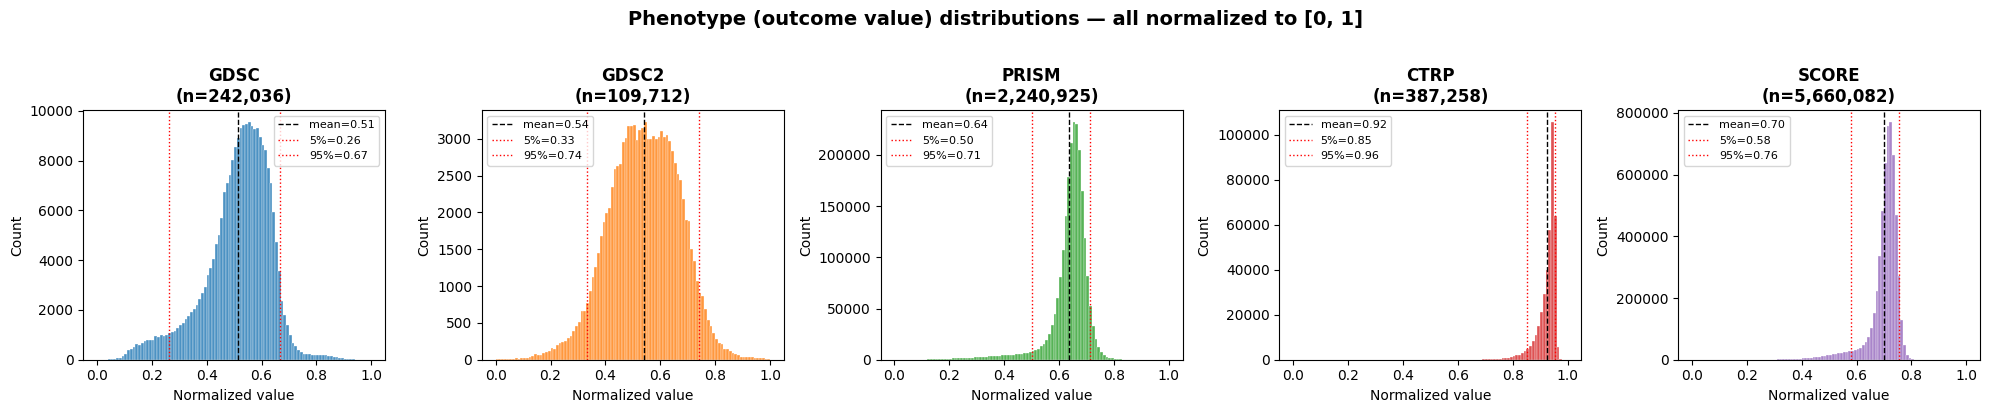

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = {"GDSC": "#1f77b4", "GDSC2": "#ff7f0e", "PRISM": "#2ca02c", "CTRP": "#d62728", "SCORE": "#9467bd"}

for ax, (name, adata) in zip(axes, datasets.items()):
    x = adata.X.flatten()
    ax.hist(x, bins=100, color=colors[name], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{name}\n(n={len(x):,})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Normalized value")
    ax.set_ylabel("Count")
    ax.axvline(x.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={x.mean():.2f}")
    # Mark the 5th and 95th percentiles (Prophet's "hit" thresholds)
    p5, p95 = np.percentile(x, 5), np.percentile(x, 95)
    ax.axvline(p5, color="red", linestyle=":", linewidth=1, label=f"5%={p5:.2f}")
    ax.axvline(p95, color="red", linestyle=":", linewidth=1, label=f"95%={p95:.2f}")
    ax.legend(fontsize=8)

fig.suptitle("Phenotype (outcome value) distributions — all normalized to [0, 1]", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Cell line overlap across datasets

This is critical for understanding transfer learning potential. Cell lines shared across datasets allow Prophet to learn cross-phenotype relationships for the same biological system.

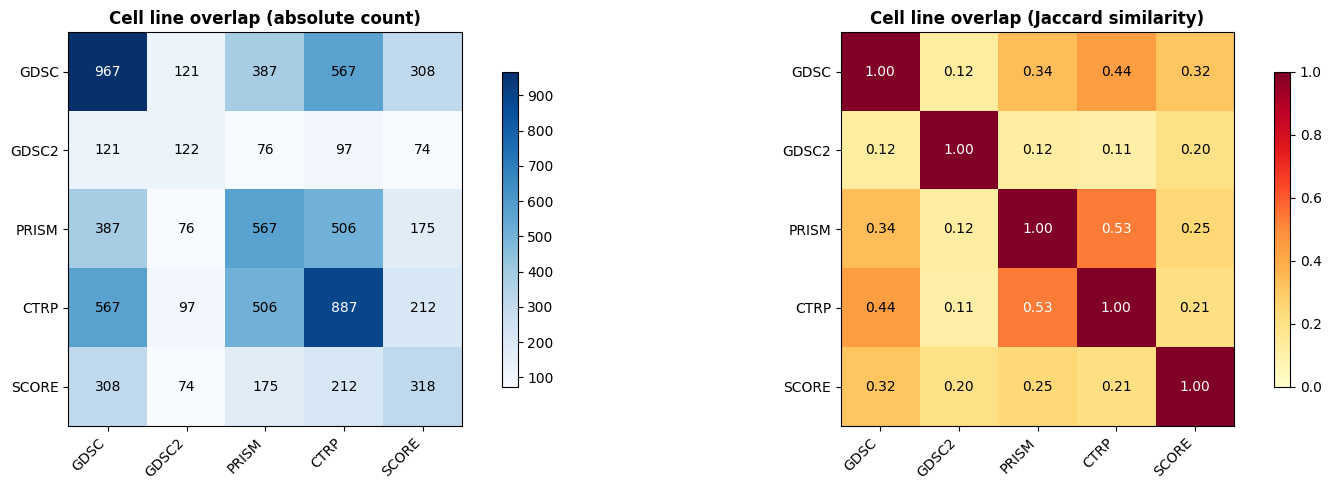


Cell lines shared across ALL drug datasets (GDSC, GDSC2, PRISM, CTRP): 71
Cell lines shared between GDSC (drug) and SCORE (genetic): 308


In [7]:
from itertools import combinations

# Collect cell line sets per dataset
cl_sets = {name: set(adata.obs["cell_line"].unique()) for name, adata in datasets.items()}
ds_names = list(cl_sets.keys())

# --- Pairwise overlap matrix ---
n = len(ds_names)
overlap_matrix = np.zeros((n, n), dtype=int)
for i, d1 in enumerate(ds_names):
    for j, d2 in enumerate(ds_names):
        overlap_matrix[i, j] = len(cl_sets[d1] & cl_sets[d2])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of absolute overlap
im = axes[0].imshow(overlap_matrix, cmap="Blues")
axes[0].set_xticks(range(n))
axes[0].set_xticklabels(ds_names, rotation=45, ha="right")
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(ds_names)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, str(overlap_matrix[i, j]), ha="center", va="center", fontsize=10,
                     color="white" if overlap_matrix[i, j] > overlap_matrix.max() * 0.6 else "black")
axes[0].set_title("Cell line overlap (absolute count)", fontweight="bold")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Jaccard similarity
jaccard_matrix = np.zeros((n, n))
for i, d1 in enumerate(ds_names):
    for j, d2 in enumerate(ds_names):
        union = len(cl_sets[d1] | cl_sets[d2])
        jaccard_matrix[i, j] = len(cl_sets[d1] & cl_sets[d2]) / union if union > 0 else 0

im2 = axes[1].imshow(jaccard_matrix, cmap="YlOrRd", vmin=0, vmax=1)
axes[1].set_xticks(range(n))
axes[1].set_xticklabels(ds_names, rotation=45, ha="right")
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(ds_names)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f"{jaccard_matrix[i, j]:.2f}", ha="center", va="center", fontsize=10,
                     color="white" if jaccard_matrix[i, j] > 0.5 else "black")
axes[1].set_title("Cell line overlap (Jaccard similarity)", fontweight="bold")
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# Print the cell lines shared across ALL drug datasets
drug_datasets = ["GDSC", "GDSC2", "PRISM", "CTRP"]
shared_all_drugs = cl_sets["GDSC"] & cl_sets["GDSC2"] & cl_sets["PRISM"] & cl_sets["CTRP"]
print(f"\nCell lines shared across ALL drug datasets ({', '.join(drug_datasets)}): {len(shared_all_drugs)}")

# Cell lines shared between drug and genetic datasets
shared_drug_genetic = cl_sets["GDSC"] & cl_sets["SCORE"]
print(f"Cell lines shared between GDSC (drug) and SCORE (genetic): {len(shared_drug_genetic)}")

## 5. Perturbation (compound / gene) overlap across datasets

Drug datasets may share compounds. SCORE is genetic (CRISPR KO) — no overlap with drug datasets by definition.

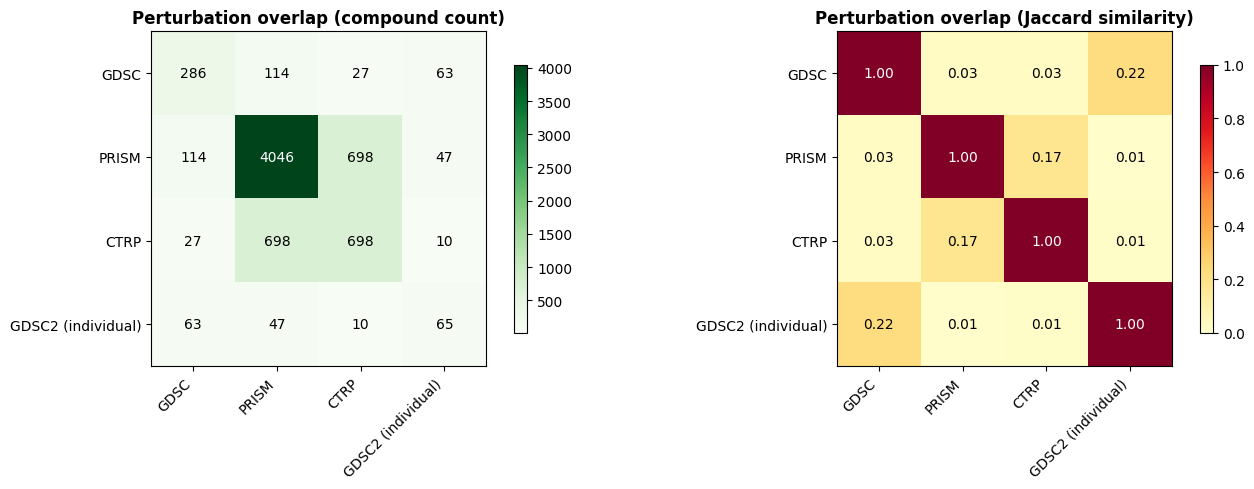


Total unique compounds across GDSC+PRISM+CTRP: 4218
Total unique genes in SCORE: 17799


In [8]:
# Perturbation overlap — only meaningful for drug datasets
# SCORE uses gene names, drug datasets use compound names
# For GDSC2, perturbations are combinations ("drug1;drug2"), extract individual drugs
drug_ds_names = ["GDSC", "PRISM", "CTRP"]

pert_sets = {}
for name in drug_ds_names:
    # Use pert_compound which is the normalized compound name
    pert_sets[name] = set(datasets[name].obs["pert_compound"].unique())

# For GDSC2, split combinatorial names into individual drugs
gdsc2_compounds = set()
for p in datasets["GDSC2"].obs["pert_compound"].unique():
    for drug in str(p).split("_"):
        gdsc2_compounds.add(drug.strip())
pert_sets["GDSC2 (individual)"] = gdsc2_compounds

drug_ds_names_ext = drug_ds_names + ["GDSC2 (individual)"]

n = len(drug_ds_names_ext)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute overlap
overlap_pert = np.zeros((n, n), dtype=int)
for i, d1 in enumerate(drug_ds_names_ext):
    for j, d2 in enumerate(drug_ds_names_ext):
        overlap_pert[i, j] = len(pert_sets[d1] & pert_sets[d2])

im = axes[0].imshow(overlap_pert, cmap="Greens")
axes[0].set_xticks(range(n))
axes[0].set_xticklabels(drug_ds_names_ext, rotation=45, ha="right")
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(drug_ds_names_ext)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, str(overlap_pert[i, j]), ha="center", va="center", fontsize=10,
                     color="white" if overlap_pert[i, j] > overlap_pert.max() * 0.6 else "black")
axes[0].set_title("Perturbation overlap (compound count)", fontweight="bold")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Jaccard
jaccard_pert = np.zeros((n, n))
for i, d1 in enumerate(drug_ds_names_ext):
    for j, d2 in enumerate(drug_ds_names_ext):
        union = len(pert_sets[d1] | pert_sets[d2])
        jaccard_pert[i, j] = len(pert_sets[d1] & pert_sets[d2]) / union if union > 0 else 0

im2 = axes[1].imshow(jaccard_pert, cmap="YlOrRd", vmin=0, vmax=1)
axes[1].set_xticks(range(n))
axes[1].set_xticklabels(drug_ds_names_ext, rotation=45, ha="right")
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(drug_ds_names_ext)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f"{jaccard_pert[i, j]:.2f}", ha="center", va="center", fontsize=10,
                     color="white" if jaccard_pert[i, j] > 0.5 else "black")
axes[1].set_title("Perturbation overlap (Jaccard similarity)", fontweight="bold")
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print(f"\nTotal unique compounds across GDSC+PRISM+CTRP: {len(pert_sets['GDSC'] | pert_sets['PRISM'] | pert_sets['CTRP'])}")
print(f"Total unique genes in SCORE: {datasets['SCORE'].obs['pert_name'].nunique()}")

## 6. Experimental matrix sparsity — how complete is the cell line × perturbation grid?

Prophet needs to predict missing entries in the cell line × perturbation matrix. Dense matrices are easier to learn from.

/tmp/ipykernel_410329/2856519175.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cl_counts = obs.groupby("cell_line")["pert_name"].nunique().sort_values(ascending=False)
/tmp/ipykernel_410329/2856519175.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pert_counts = obs.groupby("pert_name")["cell_line"].nunique().sort_values(ascending=False)
/tmp/ipykernel_410329/2856519175.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

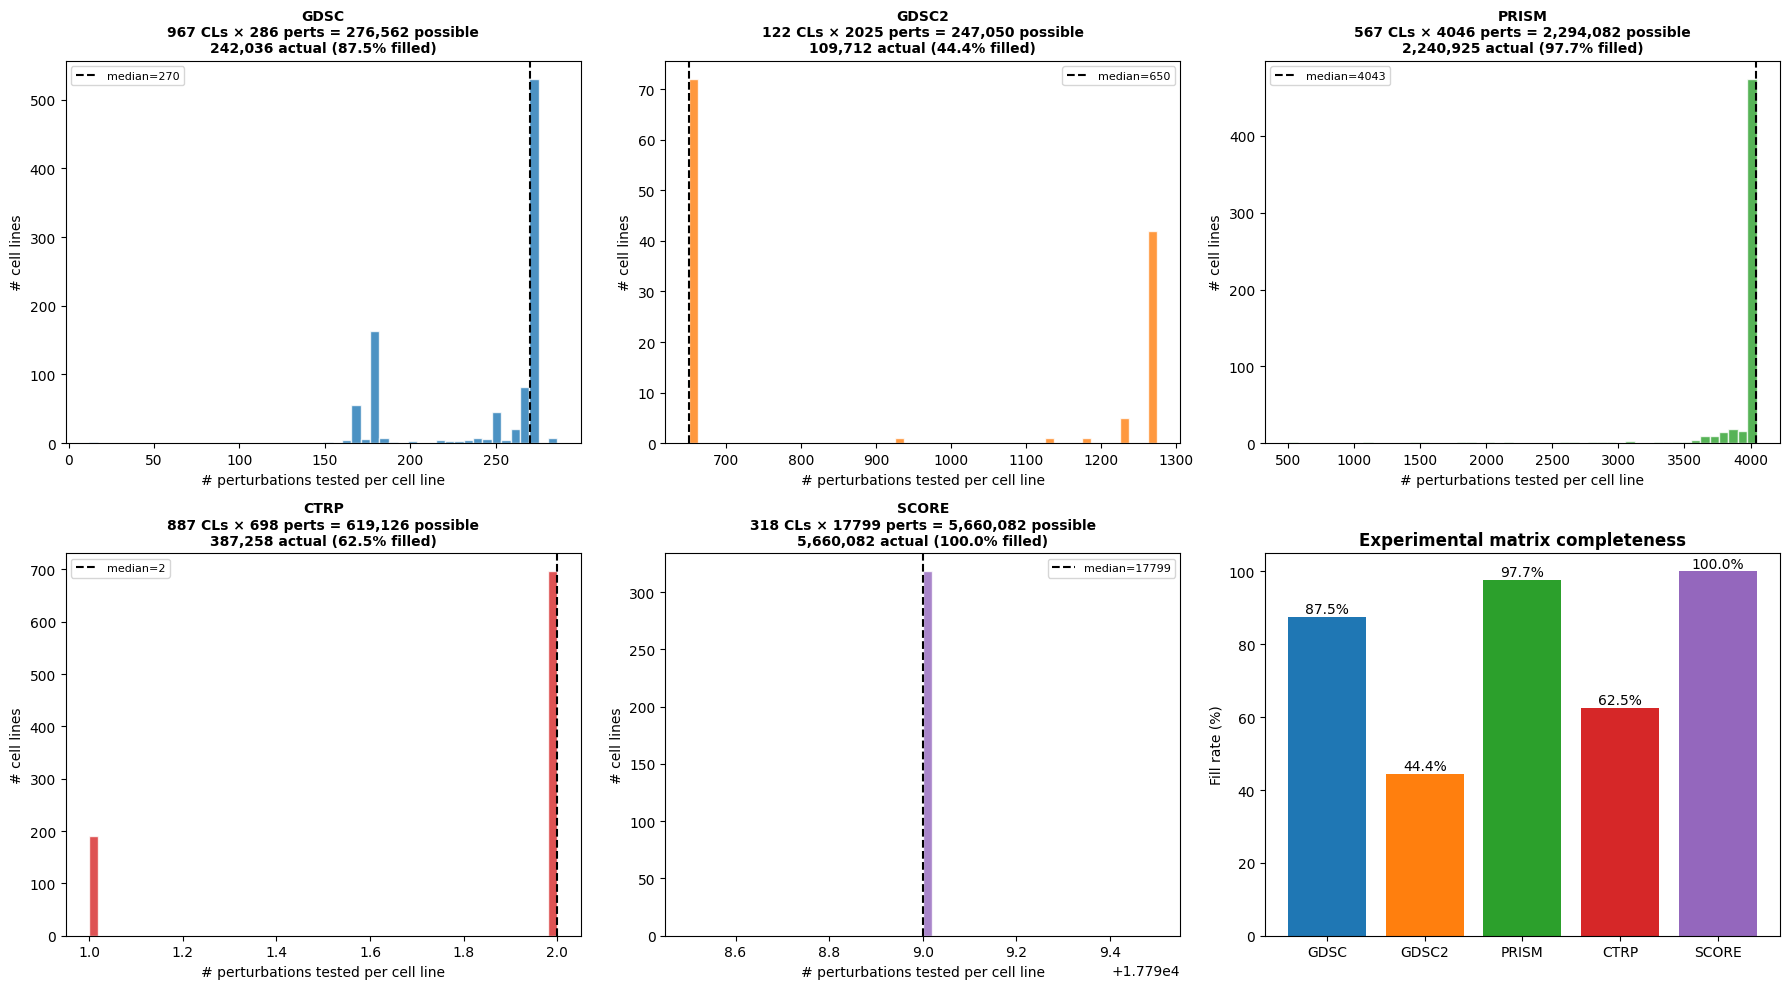

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, adata) in enumerate(datasets.items()):
    ax = axes[idx]
    obs = adata.obs
    
    # Count how many perturbations each cell line was tested with
    cl_counts = obs.groupby("cell_line")["pert_name"].nunique().sort_values(ascending=False)
    # Count how many cell lines each perturbation was tested in
    pert_counts = obs.groupby("pert_name")["cell_line"].nunique().sort_values(ascending=False)
    
    n_cl = obs["cell_line"].nunique()
    n_pert = obs["pert_name"].nunique()
    max_possible = n_cl * n_pert
    actual = len(obs)
    fill_rate = actual / max_possible * 100
    
    # Plot: distribution of perturbations per cell line
    ax.hist(cl_counts.values, bins=50, color=colors.get(name, "gray"), alpha=0.8, edgecolor="white")
    ax.set_xlabel("# perturbations tested per cell line")
    ax.set_ylabel("# cell lines")
    ax.set_title(f"{name}\n{n_cl} CLs × {n_pert} perts = {max_possible:,} possible\n"
                 f"{actual:,} actual ({fill_rate:.1f}% filled)", fontsize=10, fontweight="bold")
    ax.axvline(cl_counts.median(), color="black", linestyle="--", label=f"median={cl_counts.median():.0f}")
    ax.legend(fontsize=8)

# Use last subplot for summary bar chart
ax = axes[5]
ds_list = list(datasets.keys())
fill_rates = []
for name in ds_list:
    obs = datasets[name].obs
    n_cl = obs["cell_line"].nunique()
    n_pert = obs["pert_name"].nunique()
    fill_rates.append(len(obs) / (n_cl * n_pert) * 100)
bars = ax.bar(ds_list, fill_rates, color=[colors.get(n, "gray") for n in ds_list])
ax.set_ylabel("Fill rate (%)")
ax.set_title("Experimental matrix completeness", fontweight="bold")
for bar, rate in zip(bars, fill_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{rate:.1f}%", 
            ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 8. Phenotype variance per perturbation — which perturbations have cell-line-specific effects?

If a drug has the same IC50 across all cell lines, there's nothing cell-line-specific to learn. We want perturbations with HIGH variance across cell lines — those are the informative ones for CellFlow's distributional modeling.

/tmp/ipykernel_410329/4111242313.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pert_var = obs.groupby("pert_name")["value"].var().dropna()
/tmp/ipykernel_410329/4111242313.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pert_var = obs.groupby("pert_name")["value"].var().dropna()
/tmp/ipykernel_410329/4111242313.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pert_var = obs.groupby("pert_name")["value"].var(

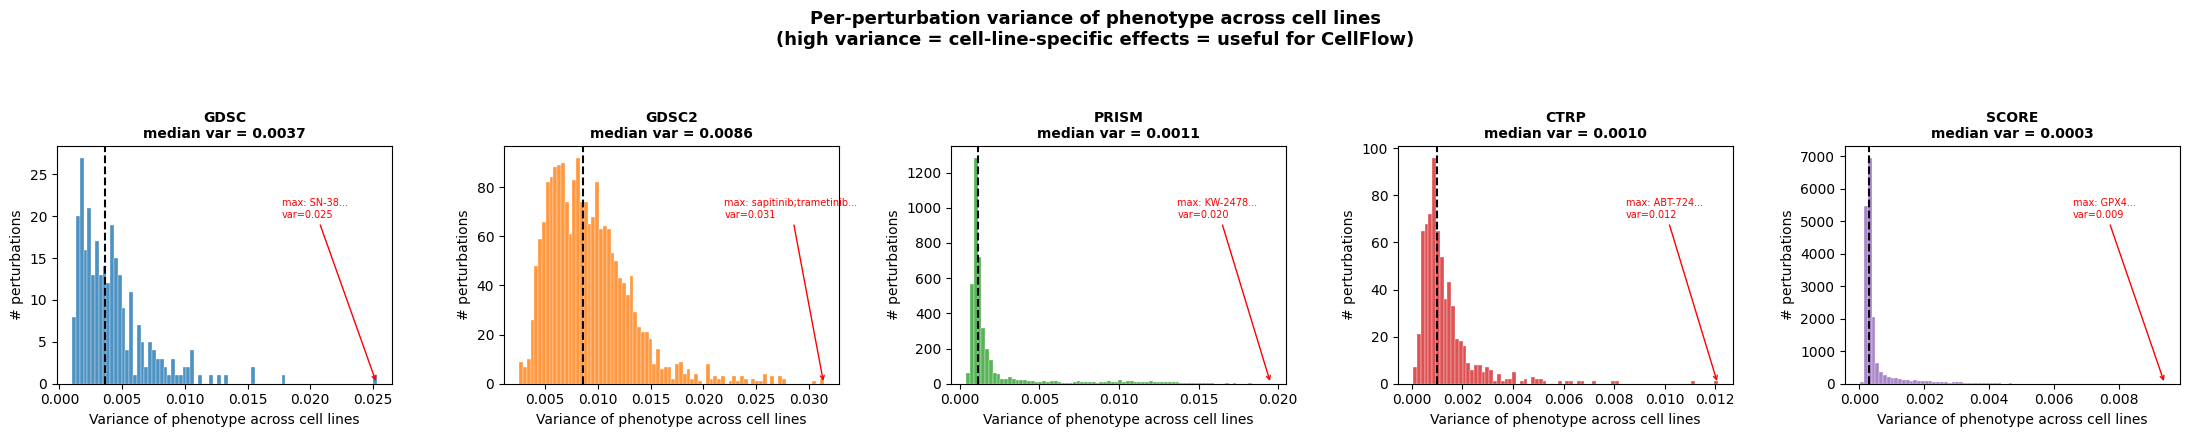

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for idx, (name, adata) in enumerate(datasets.items()):
    ax = axes[idx]
    obs = adata.obs.copy()
    obs["value"] = adata.X.flatten()
    
    # Variance of the phenotype value across cell lines, per perturbation
    pert_var = obs.groupby("pert_name")["value"].var().dropna()
    
    ax.hist(pert_var.values, bins=80, color=colors.get(name, "gray"), alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Variance of phenotype across cell lines")
    ax.set_ylabel("# perturbations")
    ax.set_title(f"{name}\nmedian var = {pert_var.median():.4f}", fontsize=10, fontweight="bold")
    ax.axvline(pert_var.median(), color="black", linestyle="--")

    # Annotate top-variance perturbation
    top_pert = pert_var.idxmax()
    ax.annotate(f"max: {top_pert[:20]}...\nvar={pert_var.max():.3f}", 
                xy=(pert_var.max(), 0), fontsize=7, color="red",
                xytext=(pert_var.max()*0.7, ax.get_ylim()[1]*0.7),
                arrowprops=dict(arrowstyle="->", color="red"))

fig.suptitle("Per-perturbation variance of phenotype across cell lines\n"
             "(high variance = cell-line-specific effects = useful for CellFlow)", 
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

## 9. UpSet plot — cell line membership across datasets

Visualize which cell lines appear in which combinations of datasets.

GDSC: 698/967 (72.2%) cell lines also appear in at least 1 other dataset
GDSC2: 122/122 (100.0%) cell lines also appear in at least 1 other dataset
PRISM: 536/567 (94.5%) cell lines also appear in at least 1 other dataset
CTRP: 715/887 (80.6%) cell lines also appear in at least 1 other dataset
SCORE: 311/318 (97.8%) cell lines also appear in at least 1 other dataset


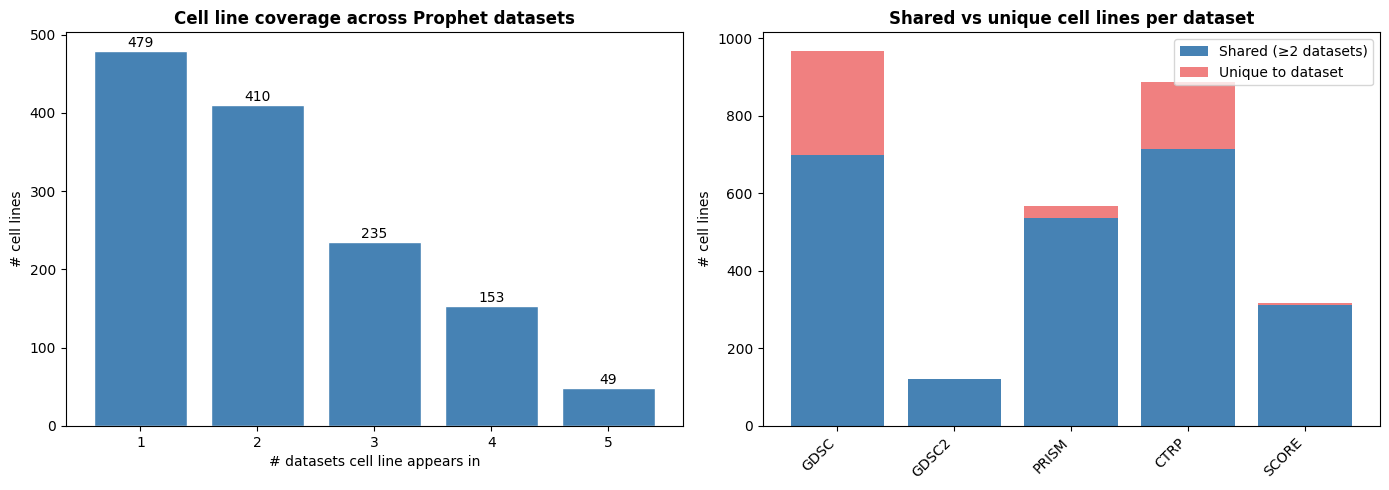

In [11]:
# Build a membership dataframe for all cell lines across all datasets
all_cls = set()
for s in cl_sets.values():
    all_cls |= s

membership = pd.DataFrame(index=sorted(all_cls))
for name, cls in cl_sets.items():
    membership[name] = membership.index.isin(cls)

# Count how many datasets each cell line appears in
membership["n_datasets"] = membership.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution: how many datasets does each cell line appear in?
counts = membership["n_datasets"].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("# datasets cell line appears in")
axes[0].set_ylabel("# cell lines")
axes[0].set_title("Cell line coverage across Prophet datasets", fontweight="bold")
for i, (x, y) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, y + 5, str(y), ha="center", fontsize=10)

# Dataset-level: what fraction of each dataset's cell lines are also in other datasets?
for name in ds_names:
    in_other = sum(1 for cl in cl_sets[name] if membership.loc[cl, "n_datasets"] > 1)
    total = len(cl_sets[name])
    print(f"{name}: {in_other}/{total} ({in_other/total*100:.1f}%) cell lines also appear in at least 1 other dataset")

# Stacked bar: per dataset, how many CLs are unique vs shared
unique_counts = []
shared_counts = []
for name in ds_names:
    unique = sum(1 for cl in cl_sets[name] if membership.loc[cl, "n_datasets"] == 1)
    shared = len(cl_sets[name]) - unique
    unique_counts.append(unique)
    shared_counts.append(shared)

x_pos = range(len(ds_names))
axes[1].bar(x_pos, shared_counts, color="steelblue", label="Shared (≥2 datasets)")
axes[1].bar(x_pos, unique_counts, bottom=shared_counts, color="lightcoral", label="Unique to dataset")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ds_names, rotation=45, ha="right")
axes[1].set_ylabel("# cell lines")
axes[1].set_title("Shared vs unique cell lines per dataset", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. CellFlow datasets — check overlap with Prophet datasets

CellFlow operates on single-cell perturbation data (scRNA-seq). Prophet operates on bulk/aggregate phenotypes. Understanding the overlap helps design a combined approach.

**Key question**: Do any CellFlow datasets (sciPlex3, combosciplex, etc.) share cell lines or drugs with Prophet datasets?

In [12]:
# Load CellFlow datasets to check overlap
CELLFLOW_DIR = "/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert"

cellflow_datasets = {}
cellflow_files = [f for f in os.listdir(CELLFLOW_DIR) if f.endswith(".h5ad") and "_w_" not in f]
print(f"CellFlow dataset files: {cellflow_files}\n")

for f in cellflow_files[:-4]:
    path = os.path.join(CELLFLOW_DIR, f)
    name = f.replace(".h5ad", "").replace("_se", "")
    try:
        adata = ad.read_h5ad(path, backed="r")
        print(f"{name}:")
        print(f"  Shape: {adata.shape}")
        # Look for cell line and drug columns
        for col in ["cell_line", "cell_type", "pert_compound", "drug_0", "drug_1", "pert_name", "perturbation"]:
            if col in adata.obs.columns:
                vals = adata.obs[col].unique()
                print(f"  {col}: {len(vals)} unique — {list(vals[:5])}")
        print()
        cellflow_datasets[name] = adata
    except Exception as e:
        print(f"  Error loading {name}: {e}\n")

CellFlow dataset files: ['tahoe_sw48.h5ad', 'tahoe_aspc_1.h5ad', 'tahoe_panc_1.h5ad', 'chang22.h5ad', 'mcfarland2020.h5ad', 'tahoe_snu_1.h5ad', 'srivatsan20_sciplex3.h5ad', 'combosciplex_se.h5ad', 'aissa21.h5ad', 'zhao21.h5ad', 'srivatsan20_sciplex4.h5ad', 'srivatsan20_sciplex2.h5ad', 'tahoe_hop62.h5ad', 'tahoe_h4.h5ad']

tahoe_sw48:
  Shape: (849525, 62710)
  cell_line: 1 unique — ['CVCL_1724']
  pert_compound: 368 unique — ['Infigratinib', 'Everolimus', 'Pemigatinib', 'Capivasertib', 'Gemcitabine']
  drug_0: 368 unique — ['Infigratinib', 'Everolimus', 'Pemigatinib', 'Capivasertib', 'Gemcitabine']
  drug_1: 1 unique — ['control']

tahoe_aspc_1:
  Shape: (2026821, 62710)
  cell_line: 1 unique — ['CVCL_0152']
  pert_compound: 368 unique — ['Infigratinib', 'Everolimus', 'Pemigatinib', 'Capivasertib', 'Gemcitabine']
  drug_0: 368 unique — ['Infigratinib', 'Everolimus', 'Pemigatinib', 'Capivasertib', 'Gemcitabine']
  drug_1: 1 unique — ['control']

tahoe_panc_1:
  Shape: (3766070, 62710)
 

In [13]:
# Cross-reference: which CellFlow drugs / cell lines appear in Prophet datasets?
# Collect all Prophet compounds and cell lines
prophet_all_compounds = set()
for name in ["GDSC", "PRISM", "CTRP"]:
    prophet_all_compounds |= set(datasets[name].obs["pert_compound"].str.lower().unique())

prophet_all_cls = set()
for name in datasets:
    prophet_all_cls |= set(datasets[name].obs["cell_line"].str.lower().unique())

prophet_all_genes = set(datasets["SCORE"].obs["pert_name"].str.upper().unique())

print(f"Prophet total unique compounds (lowercased): {len(prophet_all_compounds)}")
print(f"Prophet total unique cell lines (lowercased): {len(prophet_all_cls)}")
print(f"Prophet total unique gene KOs (SCORE): {len(prophet_all_genes)}")
print()

# For each CellFlow dataset, check overlap
for cf_name, cf_adata in cellflow_datasets.items():
    print(f"--- {cf_name} ---")
    obs = cf_adata.obs
    
    # Cell line overlap
    for cl_col in ["cell_line", "cell_type"]:
        if cl_col in obs.columns:
            cf_cls = set(obs[cl_col].str.lower().unique())
            overlap_cl = cf_cls & prophet_all_cls
            print(f"  {cl_col} overlap with Prophet: {len(overlap_cl)}/{len(cf_cls)} "
                  f"({len(overlap_cl)/len(cf_cls)*100:.0f}%) — {list(overlap_cl)[:5]}")
    
    # Drug overlap
    for drug_col in ["pert_compound", "drug_0", "drug_1", "pert_name"]:
        if drug_col in obs.columns:
            cf_drugs = set(obs[drug_col].str.lower().dropna().unique()) - {"control", "nan", "vehicle"}
            if len(cf_drugs) > 0 and len(cf_drugs) < 10000:  # skip gene columns
                overlap_drug = cf_drugs & prophet_all_compounds
                print(f"  {drug_col} overlap with Prophet compounds: {len(overlap_drug)}/{len(cf_drugs)} "
                      f"({len(overlap_drug)/len(cf_drugs)*100:.0f}%) — {list(overlap_drug)[:5]}")
    print()

Prophet total unique compounds (lowercased): 4218
Prophet total unique cell lines (lowercased): 1326
Prophet total unique gene KOs (SCORE): 17799

--- tahoe_sw48 ---
  cell_line overlap with Prophet: 0/1 (0%) — []
  pert_compound overlap with Prophet compounds: 167/368 (45%) — ['nevirapine', 'saquinavir', 'posaconazole', 'eplerenone', 'rosiglitazone']
  drug_0 overlap with Prophet compounds: 167/367 (46%) — ['nevirapine', 'saquinavir', 'posaconazole', 'eplerenone', 'rosiglitazone']

--- tahoe_aspc_1 ---
  cell_line overlap with Prophet: 0/1 (0%) — []
  pert_compound overlap with Prophet compounds: 167/368 (45%) — ['nevirapine', 'saquinavir', 'posaconazole', 'eplerenone', 'rosiglitazone']
  drug_0 overlap with Prophet compounds: 167/367 (46%) — ['nevirapine', 'saquinavir', 'posaconazole', 'eplerenone', 'rosiglitazone']

--- tahoe_panc_1 ---
  cell_line overlap with Prophet: 0/1 (0%) — []
  pert_compound overlap with Prophet compounds: 167/368 (45%) — ['nevirapine', 'saquinavir', 'posaco

## 12. GDSC deep dive — this is the best candidate for Prophet+CellFlow integration

GDSC has:
- Many cell lines (967) — rich cell state diversity
- Moderate compounds (286) — manageable perturbation space
- Dense experimental matrix
- Single-cell counterpart exists (e.g., McFarland 2020 has GDSC cell lines with scRNA-seq)

Let's look at the structure in more detail.

/tmp/ipykernel_410329/3273480777.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = obs.pivot_table(index="cell_line", columns="pert_name", values="value", aggfunc="mean")


GDSC experimental matrix: 967 cell lines × 286 drugs
Fill rate: 85.1%
NaN entries: 41147


/tmp/ipykernel_410329/3273480777.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cl_drug_counts = obs.groupby("cell_line")["pert_name"].nunique()
/tmp/ipykernel_410329/3273480777.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drug_means = obs.groupby("pert_name")["value"].mean().sort_values()


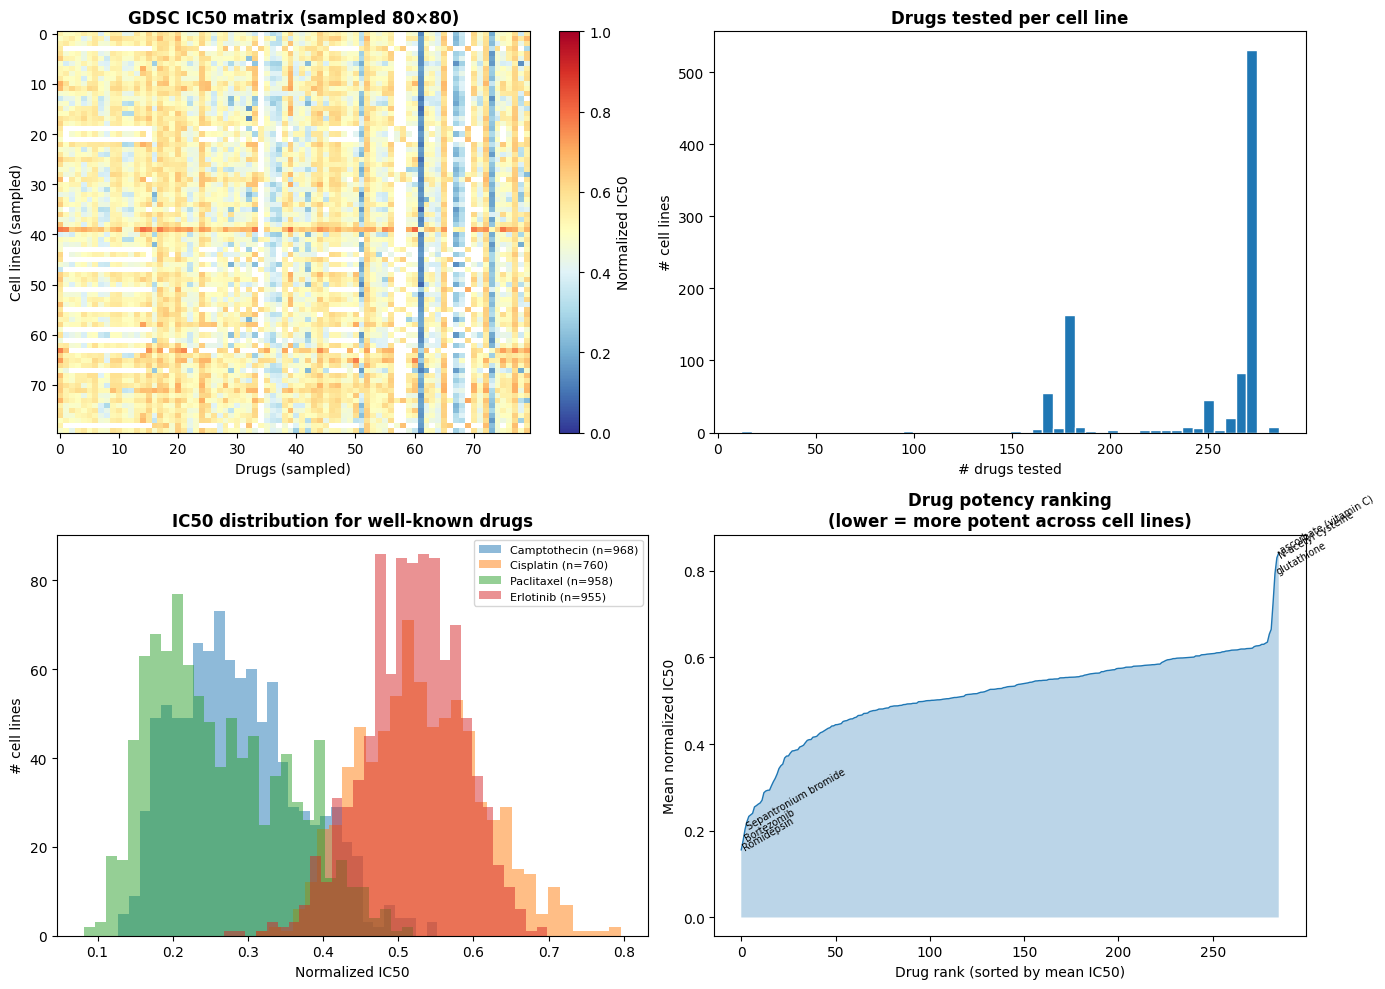

In [14]:
gdsc = datasets["GDSC"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Heatmap of the experimental matrix (sampled for visualization)
obs = gdsc.obs.copy()
obs["value"] = gdsc.X.flatten()

# Pivot to matrix form
pivot = obs.pivot_table(index="cell_line", columns="pert_name", values="value", aggfunc="mean")
print(f"GDSC experimental matrix: {pivot.shape[0]} cell lines × {pivot.shape[1]} drugs")
print(f"Fill rate: {pivot.notna().sum().sum() / (pivot.shape[0] * pivot.shape[1]) * 100:.1f}%")
print(f"NaN entries: {pivot.isna().sum().sum()}")

# Sample for visualization
n_sample_cl = min(80, pivot.shape[0])
n_sample_drug = min(80, pivot.shape[1])
pivot_sample = pivot.iloc[:n_sample_cl, :n_sample_drug]

im = axes[0, 0].imshow(pivot_sample.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=1)
axes[0, 0].set_xlabel("Drugs (sampled)")
axes[0, 0].set_ylabel("Cell lines (sampled)")
axes[0, 0].set_title(f"GDSC IC50 matrix (sampled {n_sample_cl}×{n_sample_drug})", fontweight="bold")
plt.colorbar(im, ax=axes[0, 0], label="Normalized IC50")

# (b) Distribution of # drugs tested per cell line
cl_drug_counts = obs.groupby("cell_line")["pert_name"].nunique()
axes[0, 1].hist(cl_drug_counts.values, bins=50, color="#1f77b4", edgecolor="white")
axes[0, 1].set_xlabel("# drugs tested")
axes[0, 1].set_ylabel("# cell lines")
axes[0, 1].set_title("Drugs tested per cell line", fontweight="bold")

# (c) Distribution of IC50 values for a few well-known drugs
well_known = ["Camptothecin", "Doxorubicin", "Cisplatin", "Paclitaxel", "Erlotinib"]
available = [d for d in well_known if d in obs["pert_name"].values]
for drug in available:
    vals = obs[obs["pert_name"] == drug]["value"].values
    axes[1, 0].hist(vals, bins=30, alpha=0.5, label=f"{drug} (n={len(vals)})")
axes[1, 0].set_xlabel("Normalized IC50")
axes[1, 0].set_ylabel("# cell lines")
axes[1, 0].set_title("IC50 distribution for well-known drugs", fontweight="bold")
axes[1, 0].legend(fontsize=8)

# (d) Mean IC50 per drug — sorted
drug_means = obs.groupby("pert_name")["value"].mean().sort_values()
axes[1, 1].plot(range(len(drug_means)), drug_means.values, color="#1f77b4", linewidth=1)
axes[1, 1].fill_between(range(len(drug_means)), drug_means.values, alpha=0.3)
axes[1, 1].set_xlabel("Drug rank (sorted by mean IC50)")
axes[1, 1].set_ylabel("Mean normalized IC50")
axes[1, 1].set_title("Drug potency ranking\n(lower = more potent across cell lines)", fontweight="bold")

# Annotate extremes
for i, (name, val) in enumerate(list(drug_means.head(3).items()) + list(drug_means.tail(3).items())):
    rank = list(drug_means.index).index(name)
    axes[1, 1].annotate(name, (rank, val), fontsize=7, rotation=30, ha="left")

plt.tight_layout()
plt.show()

## 13. Thinking about Prophet + CellFlow integration

### What Prophet provides:
- **Scalar phenotype predictions** (IC50, viability, essentiality) for any (cell line, perturbation) pair
- Trained on 4.7M experiments across diverse phenotypes → strong prior on drug-cell interactions
- Activity-based fingerprints: perturbation embeddings informed by phenotypic effects

### What CellFlow provides:
- **Distributional predictions** at single-cell resolution (full gene expression distribution)
- Flow matching that maps control → perturbed cell distributions
- Handles combinatorial perturbations and heterogeneous cell populations

### Potential integration strategies:

**Strategy A: Prophet embeddings as CellFlow condition embeddings**
- Use Prophet's learned experiment embedding (CLS token output) as the condition input for CellFlow
- Prophet's embedding captures functional drug effects across hundreds of cell lines
- This is richer than raw molecular fingerprints (CellFlow's current drug encoding)

**Strategy B: Prophet as an auxiliary loss / regularizer**
- Train CellFlow with an additional head that predicts Prophet's scalar phenotype from the generated distribution
- E.g., predict viability from the generated single-cell distribution → grounds CellFlow in aggregate biology

**Strategy C: Multi-scale prediction**  
- Prophet screens 1000s of perturbations cheaply (scalar) → identifies hits
- CellFlow predicts detailed single-cell distributions for the top hits only
- Sequential workflow: Prophet for coarse screening, CellFlow for detailed analysis

**Strategy D: Shared perturbation/cell line representations**
- Pre-train perturbation and cell line encoders on Prophet's massive dataset
- Transfer these encoders to CellFlow (instead of training CellFlow's encoders from scratch on small scRNA-seq data)
- Lowrank finetune?


In [16]:
corrected = sc.read_h5ad("/lustre/groups/ml01/workspace/weixu.wang/panflow_cfp/X_scimilarity_correct.h5ad", backed="r")
print(f"Corrected dataset shape: {corrected.shape}")

Corrected dataset shape: (14690714, 128)


In [19]:
corrected.obs.index

Index(['AAAAACGGTCTT-GSM4869650', 'AAAAACTTGTAC-GSM4869650',
       'AAAAAGAACCTT-GSM4869650', 'AAAAAGAGTCGA-GSM4869650',
       'AAAAAGCATGGA-GSM4869650', 'AAAAAGCCCCTG-GSM4869650',
       'AAAAAGCGACAT-GSM4869650', 'AAAAAGGGCTAC-GSM4869650',
       'AAAAAGTGGACA-GSM4869650', 'AAAAAGTTAGTA-GSM4869650',
       ...
       'AGGCAAGATGCG-PW032-705', 'GGCTCTCGACGA-PW032-705',
       'GCGGGCCTCAAC-PW032-705', 'ACTCTTACTCAG-PW032-705',
       'GACCATTAGAAG-PW032-705', 'GCTCCTCGCACT-PW032-705',
       'TACGGAATGCGT-PW032-705', 'ACCGCAAGTACC-PW032-705',
       'CGTGTTTTGCGA-PW032-705', 'ATCTAATATCAA-PW032-705'],
      dtype='object', length=14690714)

## 14. Feasibility: Prophet `perturbations_after_transformer` as CellFlow condition embedding

**Idea**: For each (cell_line, drug) pair in CellFlow's scRNA-seq data, query Prophet to get a cell-line-contextualized perturbation embedding (512-dim). Use this as CellFlow's condition input instead of raw molecular fingerprints.

**Why better than raw fingerprints**: Prophet's perturbation token has attended to the cell line token through 8 transformer layers — learned from 4.7M experiments. Same drug → DIFFERENT embeddings for different cell lines.

**Requirements**: CellFlow cell lines need CCLE profiles, CellFlow drugs need fingerprints.

In [ ]:
# Check which CellFlow datasets have cell lines in Prophet's training data
# Prophet uses CCLE cell lines — any cell line with CCLE bulk RNA-seq is compatible

# All Prophet cell lines (these all have CCLE profiles)
prophet_cls_lower = {cl.lower() for name in datasets for cl in datasets[name].obs['cell_line'].unique()}

print('=== CellFlow ↔ Prophet cell line overlap ===')
print(f'Prophet total cell lines: {len(prophet_cls_lower)}')
print()

for cf_name, cf_adata in cellflow_datasets.items():
    for col in ['cell_line', 'cell_type']:
        if col in cf_adata.obs.columns:
            cf_cls = set(cf_adata.obs[col].str.lower().unique())
            overlap = cf_cls & prophet_cls_lower
            print(f'{cf_name} ({col}):')
            print(f'  {len(cf_cls)} cell lines/types in CellFlow data')
            print(f'  {len(overlap)} overlap with Prophet ({len(overlap)/max(len(cf_cls),1)*100:.0f}%)')
            if overlap:
                print(f'  Shared: {list(overlap)[:10]}')
            print()

print('=== CellFlow ↔ Prophet drug overlap ===')
prophet_drugs_lower = {d.lower() for name in ['GDSC', 'PRISM', 'CTRP'] for d in datasets[name].obs['pert_compound'].unique()}
print(f'Prophet total drugs: {len(prophet_drugs_lower)}')
print()

for cf_name, cf_adata in cellflow_datasets.items():
    for col in ['drug_0', 'pert_compound', 'pert_name']:
        if col in cf_adata.obs.columns:
            cf_drugs = set(cf_adata.obs[col].str.lower().dropna().unique()) - {'control', 'nan', 'vehicle', 'dmso'}
            if 0 < len(cf_drugs) < 5000:
                overlap = cf_drugs & prophet_drugs_lower
                print(f'{cf_name} ({col}):')
                print(f'  {len(cf_drugs)} drugs in CellFlow data')
                print(f'  {len(overlap)} overlap with Prophet ({len(overlap)/max(len(cf_drugs),1)*100:.0f}%)')
                if overlap:
                    print(f'  Shared: {list(overlap)[:10]}')
                print()
                break


In [ ]:
# Visualize the integration architecture
print('''
=== Proposed Architecture: Prophet → CellFlow ===

For each condition in CellFlow (cell_line=MCF7, drug=trametinib):

  Step 1: Query Prophet
  ┌──────────────────────────────────────────────────────────┐
  │ Prophet(MCF7_ccle_emb, trametinib_fp, IC50_token)        │
  │       ↓                                                  │
  │ [CLS] [trametinib] [MCF7] [IC50]  → Transformer ×8       │
  │       ↓                                                  │
  │ perturbations_after_transformer[0] = [512-dim vector]    │
  │ This vector encodes: "how trametinib acts in MCF7"       │
  └──────────────────────────────────────────────────────────┘
                          ↓
  Step 2: Feed into CellFlow as condition embedding
  ┌──────────────────────────────────────────────────────────┐
  │ CellFlow condition = prophet_pert_emb [512-dim]          │
  │       ↓                                                  │
  │ CellFlow encoder → condition vector c                    │
  │       ↓                                                  │
  │ Flow Matching: v_θ(X_t, t, c)                            │
  │       ↓                                                  │
  │ Integrate ODE: control cells → predicted perturbed cells │
  └──────────────────────────────────────────────────────────┘

Key advantage: Prophet\'s 512-dim embedding is trained on 4.7M experiments
vs CellFlow\'s fingerprint is a fixed chemical descriptor (no biological context)

For UNSEEN drugs: Prophet can still produce an embedding if it has the
Morgan fingerprint — the tokenizer MLP generalizes to new drugs.
For UNSEEN cell lines: Prophet needs a CCLE profile. If not available,
fall back to CellFlow\'s default encoding.
''')
